# EngressNet Evaluation Plots

Customizable versions of the three quick-look figures (`sit_timeseries.png`,
`ensemble_figure.png`, `error_figure.png`) plus new time series at
**candidate points** (coastal communities: Kivalina, Shishmaref, Kotzebue, Nome, Point Hope).

This notebook reads only the files written to `<output_dir>/eval_data/` by
`save_evaluation_data()` (called automatically from `run_pipeline()` — see
`functions_engressnet.py`), so it does **not** need to reload the raw
`.nc` files, recompute the land-sea mask, or touch the model/GPU. It only
needs `numpy`, `pandas`, `matplotlib`, and `cartopy`.

**Before running:** point `EVAL_DIR` below at a run's `eval_data/`
directory (e.g. `.../results/<job_id>/eval_data`), either by running this
notebook from Casper directly, or by copying that folder to wherever
you're working.

If a run used `--no-patches`, everything below works, including the
candidate-point time series. If it used `--patches`, the domain/candidate
point time series are skipped (no single coherent grid to search — see the
note in `save_evaluation_data()`), but the ensemble and error figures still
work.

**Note:** Point Hope is added in the "Load everything" section below rather than coming from
`meta.json`, since it wasn't yet in `functions_engressnet.CANDIDATE_POINTS` when this run's
`eval_data/` was written. If you want it included automatically in future training runs (so it
shows up in `meta.json`/`candidate_point_timeseries.csv` without this notebook-side patch), add
it to `CANDIDATE_POINTS` in `functions_engressnet.py` too.

**Saved output:** every figure and table produced below is also written to
`saved_figs/<run_name>/` (next to this notebook), as `.png`/`.csv`, via the `save_fig`/
`save_table` helpers defined in the Config section. Re-running against a different `EVAL_DIR`
writes to its own `saved_figs/<run_name>/` subfolder rather than overwriting the last run's.

In [89]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display

## Config

In [90]:
# Point this at a single run's eval_data/ directory
DIR = Path("/glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_tile_fix")
[print(D.name) for D in sorted(DIR.iterdir())]

RUN = "FOSI_nopatches_2000-2009_2010-2020_5279614.casper-pbs/eval_data"
EVAL_DIR = DIR / RUN
assert EVAL_DIR.exists(), f"EVAL_DIR does not exist: {EVAL_DIR}"

print("\nEVAL_DIR:", EVAL_DIR)

FOSI_nopatches_1960-1970_2010-2020_5279610.casper-pbs
FOSI_nopatches_1970-1980_2010-2020_5279611.casper-pbs
FOSI_nopatches_1980-1990_2010-2020_5279612.casper-pbs
FOSI_nopatches_1990-2000_2010-2020_5279613.casper-pbs
FOSI_nopatches_2000-2009_2010-2020_5279614.casper-pbs

EVAL_DIR: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_tile_fix/FOSI_nopatches_2000-2009_2010-2020_5279614.casper-pbs/eval_data


In [91]:
# Every figure/table below also gets saved here, namespaced by run name so
# re-running this notebook against a different EVAL_DIR doesn't clobber the last run's output.
SAVE_DIR = Path("saved_figs") / EVAL_DIR.parent.name
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to SAVE_DIR/<name>.png."""
    fig.savefig(SAVE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def save_table(df, name):
    """Save a table (DataFrame or Series) to SAVE_DIR/<name>.csv."""
    df.to_csv(SAVE_DIR / f"{name}.csv")


print("Saving figures/tables to:", SAVE_DIR.resolve())

Saving figures/tables to: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/saved_figs/FOSI_nopatches_2000-2009_2010-2020_5279614.casper-pbs


## Load everything

In [92]:
fields = np.load(EVAL_DIR/"fields.npz")

X_test_sit_phys = fields["X_test_sit_phys"]   # (N, 1, Hlr, Wlr) low-res SIT input
Y_base_phys = fields["Y_base_phys"]           # (N, 1, H, W) bilinear baseline
Y_pred_det_phys = fields["Y_pred_det_phys"]   # (N, 1, H, W) deterministic UNet
preds_all_phys = fields["preds_all_phys"]     # (N, K_eval, 1, H, W) full ensemble
Y_pred_phys = fields["Y_pred_phys"]           # (N, 1, H, W) ensemble mean
Y_test_phys = fields["Y_test_phys"]           # (N, 1, H, W) truth
mask_test = fields["mask_test"]               # (N, C_mask, H, W) land mask, per test sample/tile
test_tile_ids = fields["test_tile_ids"]       # (N,) which tile each sample came from
land_mask = fields["land_mask"]               # (1, 1, H, W) full-domain land mask
hlat, hlon = fields["hlat"], fields["hlon"]   # full-domain high-res grid
llat, llon = fields["llat"], fields["llon"]   # full-domain low-res grid

with open(EVAL_DIR / "tile_geometry.pkl", "rb") as f:
    tile_geometry = pickle.load(f)   # list of dicts: context_lon/lat, target_lon/lat per tile

with open(EVAL_DIR / "meta.json") as f:
    meta = json.load(f)

bbox = meta["bbox"]
use_patches = meta["use_patches"]
candidate_points = meta["candidate_points"]   # {name: {"lat":.., "lon":.. (0-360)}}

sample_times_df = pd.read_csv(EVAL_DIR / "sample_times.csv", parse_dates=["time"])

print("use_patches:", use_patches)
print("N samples:", Y_test_phys.shape[0], " |  target grid:", Y_test_phys.shape[-2:])
print("Candidate points:", list(candidate_points.keys()))

use_patches: False
N samples: 132  |  target grid: (150, 310)
Candidate points: ['Kivalina', 'Shishmaref', 'Kotzebue', 'Nome', 'Point Hope']


In [93]:
# Point Hope isn't in this run's meta.json (it postdates whichever training run wrote
# eval_data/), so add it here directly. Section 2's per-point lookup works straight off the
# saved fields (nearest valid grid cell + exclusion mask), so this needs no retraining -- same
# "recompute, don't trust the precomputed file" approach already used for the other points.
POINT_HOPE_LAT = 68.3415
POINT_HOPE_LON_360 = -166.7578 % 360
candidate_points = {**candidate_points, "Point Hope": {"lat": POINT_HOPE_LAT, "lon": POINT_HOPE_LON_360}}

print("Candidate points:", list(candidate_points.keys()))

Candidate points: ['Kivalina', 'Shishmaref', 'Kotzebue', 'Nome', 'Point Hope']


## Metrics

`metrics.csv` (MAE / RMSE / bias / gradient-MAE / pattern correlation / SSIM / ice-edge error /
spread-skill ratio for Bilinear, Deterministic UNet, and Stochastic UNet Mean), written by
`run_pipeline()` next to `eval_data/`.

In [94]:
metrics_path = EVAL_DIR.parent / "metrics.csv"

if not metrics_path.exists():
    print(f"metrics.csv not found at {metrics_path}")
else:
    metrics_df = pd.read_csv(metrics_path)
    save_table(metrics_df, "00_metrics")
    display(metrics_df)

,Method,MAE,RMSE,Bias,Grad MAE,Pattern Corr,SSIM,IIEE,Coastal MAE,Coastal RMSE,Spread/Error
0,Bilinear,0.1000,0.3085,0.0098,0.0586,0.9188,0.8710,0.0000,0.2532,0.5767,NaN
1,Deterministic UNet,0.0653,0.1654,-0.0093,0.0474,0.9461,0.8959,0.1645,0.1693,0.3257,NaN
2,Stochastic UNet Mean,0.0630,0.1648,0.0047,0.0472,0.9488,0.8919,0.1055,0.1755,0.3396,2.3437


## Metrics check: is Pattern Corr spatially weighted?

`pattern_corr()` in `functions_engressnet.py` (used to build `metrics.csv` above) flattens
each sample's `(H, W)` field and computes a plain per-pixel Pearson correlation — every
grid cell counts equally, regardless of its physical area. On this regular lat/lon grid,
cell area shrinks with `cos(lat)`, so as written it is **not** area-weighted.

Recomputed below directly from the saved fields: first the exact same unweighted formula
(should reproduce the `metrics.csv` values above), then a `cos(lat)`-weighted version
(weights normalized to sum to 1 per sample, using each sample's own `target_lat` from
`tile_geometry` — this works for both `--patches` and `--no-patches` runs, since Pattern
Corr is already a per-sample, per-tile metric, unlike the domain-mean/candidate-point
sections below). The gap between the two numbers shows how much the unweighted metric is
being pulled around by the pole-ward vs. equator-ward rows of each tile.

In [95]:
def unweighted_pattern_corr(pred, truth):
    """Matches functions_engressnet.pattern_corr exactly: flatten (H, W) per
    sample, plain Pearson correlation, averaged across samples."""
    p = pred.reshape(pred.shape[0], -1)
    t = truth.reshape(truth.shape[0], -1)
    p = p - p.mean(axis=1, keepdims=True)
    t = t - t.mean(axis=1, keepdims=True)
    num = (p * t).sum(axis=1)
    den = np.sqrt((p ** 2).sum(axis=1) * (t ** 2).sum(axis=1)) + 1e-8
    return float((num / den).mean())


def coslat_weighted_pattern_corr(pred, truth, tile_ids, tile_geometry):
    """Same per-sample Pearson correlation, but with each pixel weighted by
    cos(lat) (proportional to physical cell area on a regular lat/lon grid),
    looked up per-sample from that sample's own tile geometry."""
    N, _, H, W = pred.shape
    corrs = np.empty(N)
    for i in range(N):
        target_lat = tile_geometry[int(tile_ids[i])]["target_lat"]
        w = np.cos(np.deg2rad(target_lat))[:, None] * np.ones((1, W))
        w = w / w.sum()

        p, t = pred[i, 0], truth[i, 0]
        p_anom = p - (w * p).sum()
        t_anom = t - (w * t).sum()
        num = (w * p_anom * t_anom).sum()
        den = np.sqrt((w * p_anom ** 2).sum() * (w * t_anom ** 2).sum()) + 1e-8
        corrs[i] = num / den
    return float(corrs.mean())


pattern_corr_check = []
for method_name, pred_field in [
    ("Bilinear", Y_base_phys), ("Deterministic UNet", Y_pred_det_phys), ("Stochastic UNet Mean", Y_pred_phys),
]:
    unweighted = unweighted_pattern_corr(pred_field, Y_test_phys)
    weighted = coslat_weighted_pattern_corr(pred_field, Y_test_phys, test_tile_ids, tile_geometry)
    pattern_corr_check.append({
        "Method": method_name,
        "Pattern Corr (unweighted, recomputed)": round(unweighted, 4),
        "Pattern Corr (cos-lat weighted)": round(weighted, 4),
        "Difference": round(weighted - unweighted, 4),
    })

pattern_corr_check_df = pd.DataFrame(pattern_corr_check)
save_table(pattern_corr_check_df, "00b_pattern_corr_check")
display(pattern_corr_check_df)

,Method,"Pattern Corr (unweighted, recomputed)",Pattern Corr (cos-lat weighted),Difference
0,Bilinear,0.9188,0.9171,-0.0017
1,Deterministic UNet,0.9461,0.9430,-0.0031
2,Stochastic UNet Mean,0.9488,0.9459,-0.0029


## Shared map styling

In [96]:
def rounded_boundary_path(proj, lon_min, lon_max, lat_min, lat_max, n=50):
    """Quadrilateral Axes-boundary path (in projected coords) tracing the given lon/lat box.
    Under a polar projection this comes out curved along the lat edges, so panels clipped to
    it read as "map-shaped" rather than a plain rectangular Axes frame."""
    lons = np.concatenate([
        np.linspace(lon_min, lon_max, n),
        np.full(n, lon_max),
        np.linspace(lon_max, lon_min, n),
        np.full(n, lon_min),
    ])
    lats = np.concatenate([
        np.full(n, lat_min),
        np.linspace(lat_min, lat_max, n),
        np.full(n, lat_max),
        np.linspace(lat_max, lat_min, n),
    ])
    pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
    return mpath.Path(pts[:, :2])


def make_polar_proj(bbox, n=50):
    central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
    proj = ccrs.NorthPolarStereo(central_longitude=central_lon)
    boundary_path = rounded_boundary_path(
        proj, bbox["lon_min"], bbox["lon_max"], bbox["lat_min"], bbox["lat_max"], n
    )
    return proj, boundary_path, central_lon


def style_polar_ax(ax, proj, boundary_path, bbox, lon_=None, lat_=None, pad_frac=0.001,
                    points=None, point_color="red"):
    """Coastlines, land, domain boundary, candidate-point markers, gridlines.
    If lon_/lat_ are given, zooms to that panel's actual data bounds instead
    of the full bbox domain -- the boundary is then recomputed for that same
    zoomed box (rather than reusing `boundary_path`, which is sized for the
    full `bbox` and would fall outside the zoomed view, leaving the panel
    with matplotlib's default square Axes frame instead of the intended
    map-shaped one). `points` defaults to candidate_points."""
    lon_min = bbox["lon_min"] % 360
    lon_max = bbox["lon_max"] % 360

    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    if lon_ is not None and lat_ is not None:
        lo0, lo1 = float(np.min(lon_)), float(np.max(lon_))
        la0, la1 = float(np.min(lat_)), float(np.max(lat_))
        pad_lo = (lo1 - lo0) * pad_frac or 0.5
        pad_la = (la1 - la0) * pad_frac or 0.5
        ext_lo0, ext_lo1 = lo0 - pad_lo, lo1 + pad_lo
        ext_la0, ext_la1 = la0 - pad_la, la1 + pad_la
        ax.set_extent([ext_lo0, ext_lo1, ext_la0, ext_la1], crs=ccrs.PlateCarree())
        panel_boundary = rounded_boundary_path(proj, ext_lo0, ext_lo1, ext_la0, ext_la1)
    else:
        ax.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())
        panel_boundary = boundary_path

    ax.set_boundary(panel_boundary, transform=proj)

    if points is None:
        points = candidate_points
    for name, pt in points.items():
        ax.plot(pt["lon"], pt["lat"], marker="*", color=point_color, markersize=10, transform=ccrs.PlateCarree())
        ax.text(pt["lon"] + 1, pt["lat"] + 0.35, name, color=point_color, fontsize=7, transform=ccrs.PlateCarree())

    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)


proj, boundary_path, central_lon = make_polar_proj(bbox)

## Quick look: where are the candidate points relative to the test domain?

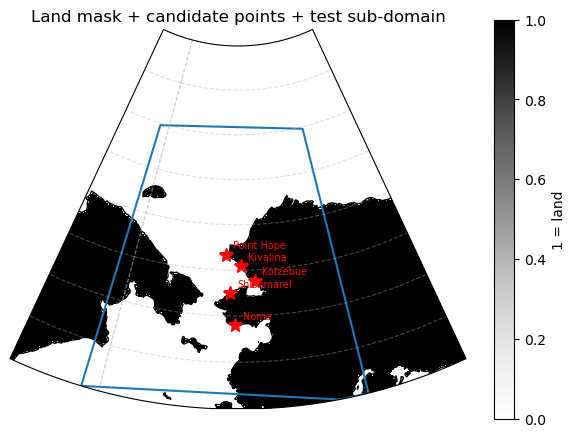

In [97]:
geo0 = tile_geometry[0] if not use_patches else None

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=proj)
cf = ax.pcolormesh(hlon, hlat, land_mask[0, 0], cmap="Greys", vmin=0, vmax=1, shading="auto", transform=ccrs.PlateCarree())
if geo0 is not None:
    ax.plot(
        [geo0["target_lon"].min(), geo0["target_lon"].max(), geo0["target_lon"].max(), geo0["target_lon"].min(), geo0["target_lon"].min()],
        [geo0["target_lat"].min(), geo0["target_lat"].min(), geo0["target_lat"].max(), geo0["target_lat"].max(), geo0["target_lat"].min()],
        color="tab:blue", linewidth=1.5, transform=ccrs.PlateCarree(), label="test sub-domain",
    )
style_polar_ax(ax, proj, boundary_path, bbox)
ax.set_title("Land mask + candidate points" + (" + test sub-domain" if geo0 is not None else ""))
fig.colorbar(cf, ax=ax, shrink=0.7, label="1 = land")
plt.tight_layout()
save_fig(fig, "00_domain_overview")
plt.show()

## 1. Domain-mean SIT time series

Recomputed directly from the saved fields (ocean-weighted mean over the
test sub-domain), so you can freely change the date range, resampling, or
styling below. Only meaningful for `use_patches=False` runs.

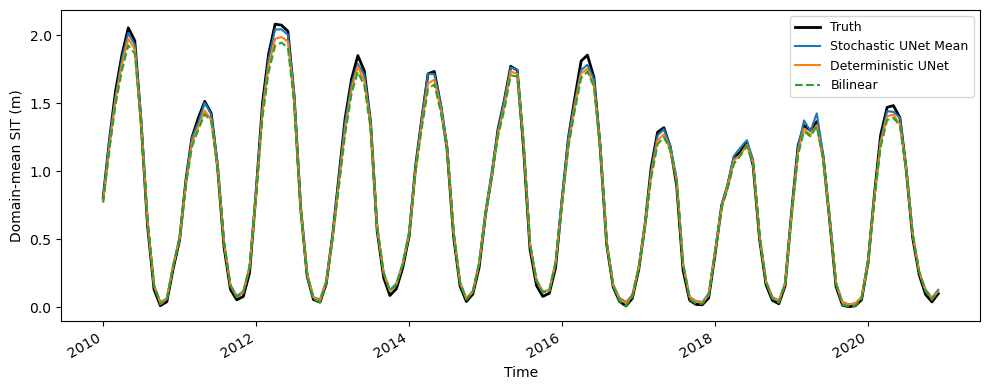

In [98]:
if use_patches:
    print("use_patches=True: no single coherent domain to average over -- skipping.")
else:
    ocean_weight = (1.0 - mask_test[0, 0]).clip(0, 1)  # (H, W); same land mask for every no-patch sample
    weight_sum = ocean_weight.sum()

    def domain_mean(field_phys):
        return (field_phys[:, 0] * ocean_weight[None, :, :]).sum(axis=(1, 2)) / weight_sum

    ts_df = sample_times_df.copy()
    ts_df["truth"] = domain_mean(Y_test_phys)
    ts_df["stochastic_unet_mean"] = domain_mean(Y_pred_phys)
    ts_df["deterministic_unet"] = domain_mean(Y_pred_det_phys)
    ts_df["bilinear"] = domain_mean(Y_base_phys)
    ts_df = ts_df.sort_values("time").reset_index(drop=True)
    save_table(ts_df, "01_domain_mean_sit_timeseries_data")

    # ---- customize here ----
    DATE_RANGE = None          # e.g. ("2006-01-01", "2010-12-31"), or None for all
    RESAMPLE = None            # e.g. "YS" (annual mean), "MS" (monthly), or None for raw samples
    METHODS = {                # label -> (column, color, linestyle)
        "Truth": ("truth", "black", "-"),
        "Stochastic UNet Mean": ("stochastic_unet_mean", "tab:blue", "-"),
        "Deterministic UNet": ("deterministic_unet", "tab:orange", "-"),
        "Bilinear": ("bilinear", "tab:green", "--"),
    }
    # -------------------------

    plot_df = ts_df
    if DATE_RANGE is not None:
        plot_df = plot_df[(plot_df["time"] >= DATE_RANGE[0]) & (plot_df["time"] <= DATE_RANGE[1])]
    if RESAMPLE is not None:
        plot_df = plot_df.set_index("time").resample(RESAMPLE).mean(numeric_only=True).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, (col, color, ls) in METHODS.items():
        ax.plot(plot_df["time"], plot_df[col], label=label, color=color, ls=ls, lw=2 if col == "truth" else 1.5)
    ax.set_ylabel("Domain-mean SIT (m)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    save_fig(fig, "01_domain_mean_sit_timeseries")
    plt.show()

    ts_df.head()


## 2. Candidate-point time series (Kivalina, Shishmaref, Kotzebue, Nome, Point Hope)

Nearest-grid-cell time series at each named point, recomputed directly from the saved fields
(same "recompute, don't trust the precomputed file" approach as section 1). The nearest-cell
search excludes both land cells *and* cells where "truth" is ~constant over time: bilinear
regridding onto the high-res target grid bleeds the land-side fill value (0) into cells right at
the coast, which pass the land mask (regridded ocean fraction > 0.5) but are still numerically
flat -- a land-only exclusion doesn't catch these, which is why some "truth" lines were flat even
though the nearest cell wasn't technically land. Doing the lookup here (rather than only reading
`candidate_point_timeseries.csv`, which used the old land-only lookup) fixes this for runs that
already finished without needing to retrain.

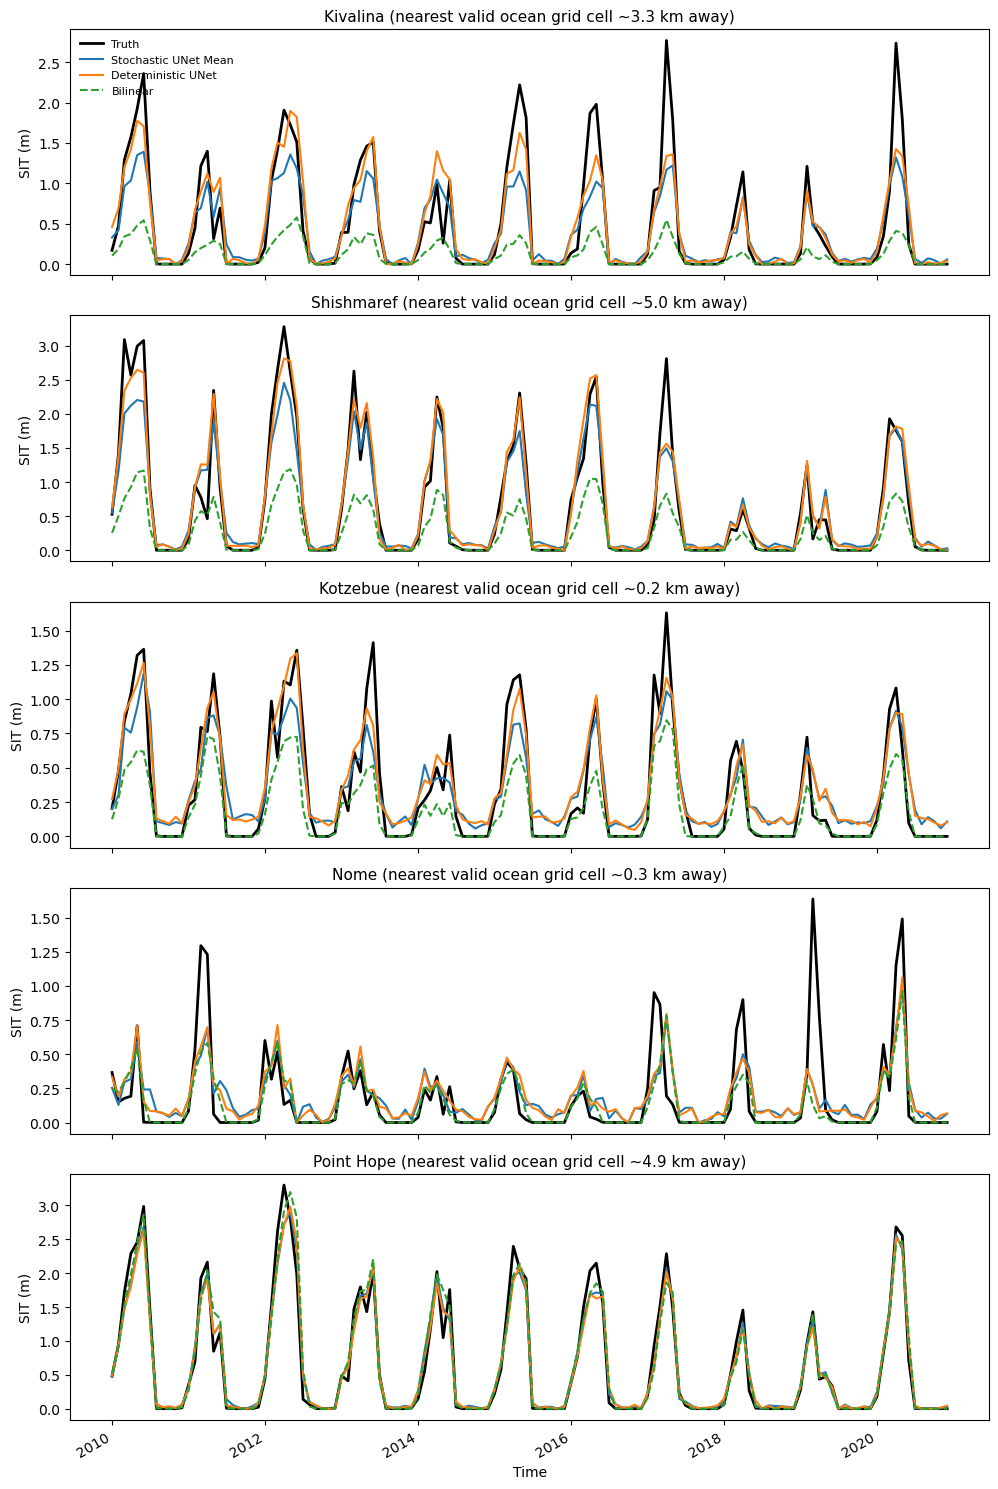

In [99]:
if use_patches:
    print("use_patches=True: no single coherent target grid to search across all test tiles -- skipping.")
else:
    def nearest_valid_index(lat_grid, lon_grid, exclude_hw, point_lat, point_lon_360):
        """Nearest (iy, ix) grid cell not flagged in exclude_hw (True/nonzero = excluded).
        point_lon_360 and lon_grid must both be in [0, 360) convention."""
        lat_grid = np.asarray(lat_grid)
        lon_grid = np.asarray(lon_grid) % 360
        dlat_deg = lat_grid[:, None] - point_lat
        dlon_deg = (lon_grid[None, :] - point_lon_360 + 180) % 360 - 180
        dlon_deg = dlon_deg * np.cos(np.deg2rad(point_lat))
        dist2 = dlat_deg ** 2 + dlon_deg ** 2
        valid = ~np.asarray(exclude_hw).astype(bool)
        dist2 = np.where(valid, dist2, np.inf)
        iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)
        return int(iy), int(ix), float(np.sqrt(dist2[iy, ix])) * 111.0

    geo = tile_geometry[0]
    target_lat, target_lon = geo["target_lat"], geo["target_lon"]
    land_mask_hw = mask_test[0, 0]   # (H, W); same crop for every no-patch sample

    # Exclude land AND cells where "truth" is ~constant over time. Bilinear
    # regridding onto the high-res target grid bleeds the land-side fill
    # value (0) into cells right at the coast -- these pass the land mask
    # (regridded ocean fraction > 0.5) but are still numerically flat, so a
    # land-only exclusion doesn't catch them (this is exactly what produced
    # the flat Kivalina/Kotzebue "truth" lines before this fix).
    FLAT_STD_TOL = 1e-6   # meters of SIT
    flat_hw = Y_test_phys[:, 0].std(axis=0) < FLAT_STD_TOL
    exclude_hw = (land_mask_hw > 0.5) | flat_hw

    fields_phys = {
        "truth": Y_test_phys, "bilinear": Y_base_phys,
        "deterministic_unet": Y_pred_det_phys, "stochastic_unet_mean": Y_pred_phys,
    }
    time_index = sample_times_df["time"]

    locations = {}
    rows = []
    for point_name, pt in candidate_points.items():
        iy, ix, dist_km = nearest_valid_index(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"])
        locations[point_name] = (iy, ix, dist_km)
        for method_name, field in fields_phys.items():
            values = field[:, 0, iy, ix]
            for t, v in zip(time_index, values):
                rows.append({"point": point_name, "method": method_name, "time": t, "value": float(v),
                             "grid_iy": iy, "grid_ix": ix, "dist_km": dist_km})
    point_df = pd.DataFrame(rows).sort_values(["point", "method", "time"]).reset_index(drop=True)
    save_table(point_df, "02_candidate_point_timeseries_data")

    # ---- customize here ----
    POINTS_TO_PLOT = list(candidate_points.keys())   # subset if you only want e.g. ["Kivalina"]
    METHOD_STYLE = {
        "truth": ("Truth", "black", "-", 2),
        "stochastic_unet_mean": ("Stochastic UNet Mean", "tab:blue", "-", 1.5),
        "deterministic_unet": ("Deterministic UNet", "tab:orange", "-", 1.5),
        "bilinear": ("Bilinear", "tab:green", "--", 1.5),
    }
    DATE_RANGE = None   # e.g. ("2006-01-01", "2010-12-31")
    # -------------------------

    fig, axs = plt.subplots(len(POINTS_TO_PLOT), 1, figsize=(10, 3 * len(POINTS_TO_PLOT)), sharex=True)
    if len(POINTS_TO_PLOT) == 1:
        axs = [axs]

    for ax, point_name in zip(axs, POINTS_TO_PLOT):
        sub = point_df[point_df["point"] == point_name]
        if DATE_RANGE is not None:
            sub = sub[(sub["time"] >= DATE_RANGE[0]) & (sub["time"] <= DATE_RANGE[1])]
        iy, ix, dist_km = locations[point_name]

        for method, (label, color, ls, lw) in METHOD_STYLE.items():
            m = sub[sub["method"] == method].sort_values("time")
            ax.plot(m["time"], m["value"], label=label, color=color, linestyle=ls, linewidth=lw)

        ax.set_title(f"{point_name} (nearest valid ocean grid cell ~{dist_km:.1f} km away)", fontsize=11)
        ax.set_ylabel("SIT (m)")
        if point_name == "Kivalina":
            ax.legend(fontsize=8, loc="upper left", frameon=False)

    axs[-1].set_xlabel("Time")
    fig.autofmt_xdate()
    plt.tight_layout()
    save_fig(fig, "02_candidate_point_timeseries")
    plt.show()

## 3. Ensemble figure (customizable)

Low-res input, bilinear, deterministic, one ensemble member, ensemble
mean, and truth, for a chosen set of test samples.

In [100]:
# ---- customize here ----
N_SAMPLES = min(3, Y_test_phys.shape[0])
MIN_ICE_THICKNESS = 0.5  # m; pixels below this don't count as "ice present"
MIN_ICE_FRAC = 0.25       # require at least this fraction of the target tile to have ice

ice_frac = (Y_test_phys[:, 0] > MIN_ICE_THICKNESS).mean(axis=(1, 2))
valid_idxs = np.where(ice_frac > MIN_ICE_FRAC)[0]

if len(valid_idxs) < N_SAMPLES:
    raise ValueError(f"Only {len(valid_idxs)} samples meet the ice criteria, need {N_SAMPLES}")

SAMPLE_IDXS = np.random.default_rng().choice(valid_idxs, N_SAMPLES, replace=False)
MEMBER_IDX = min(4, preds_all_phys.shape[1] - 1)   # which ensemble member to show in the "One Member" column
VMIN, VMAX = 0, 3
CMAP = "Blues"
SHOW_POINTS = True   # overlay candidate-point markers

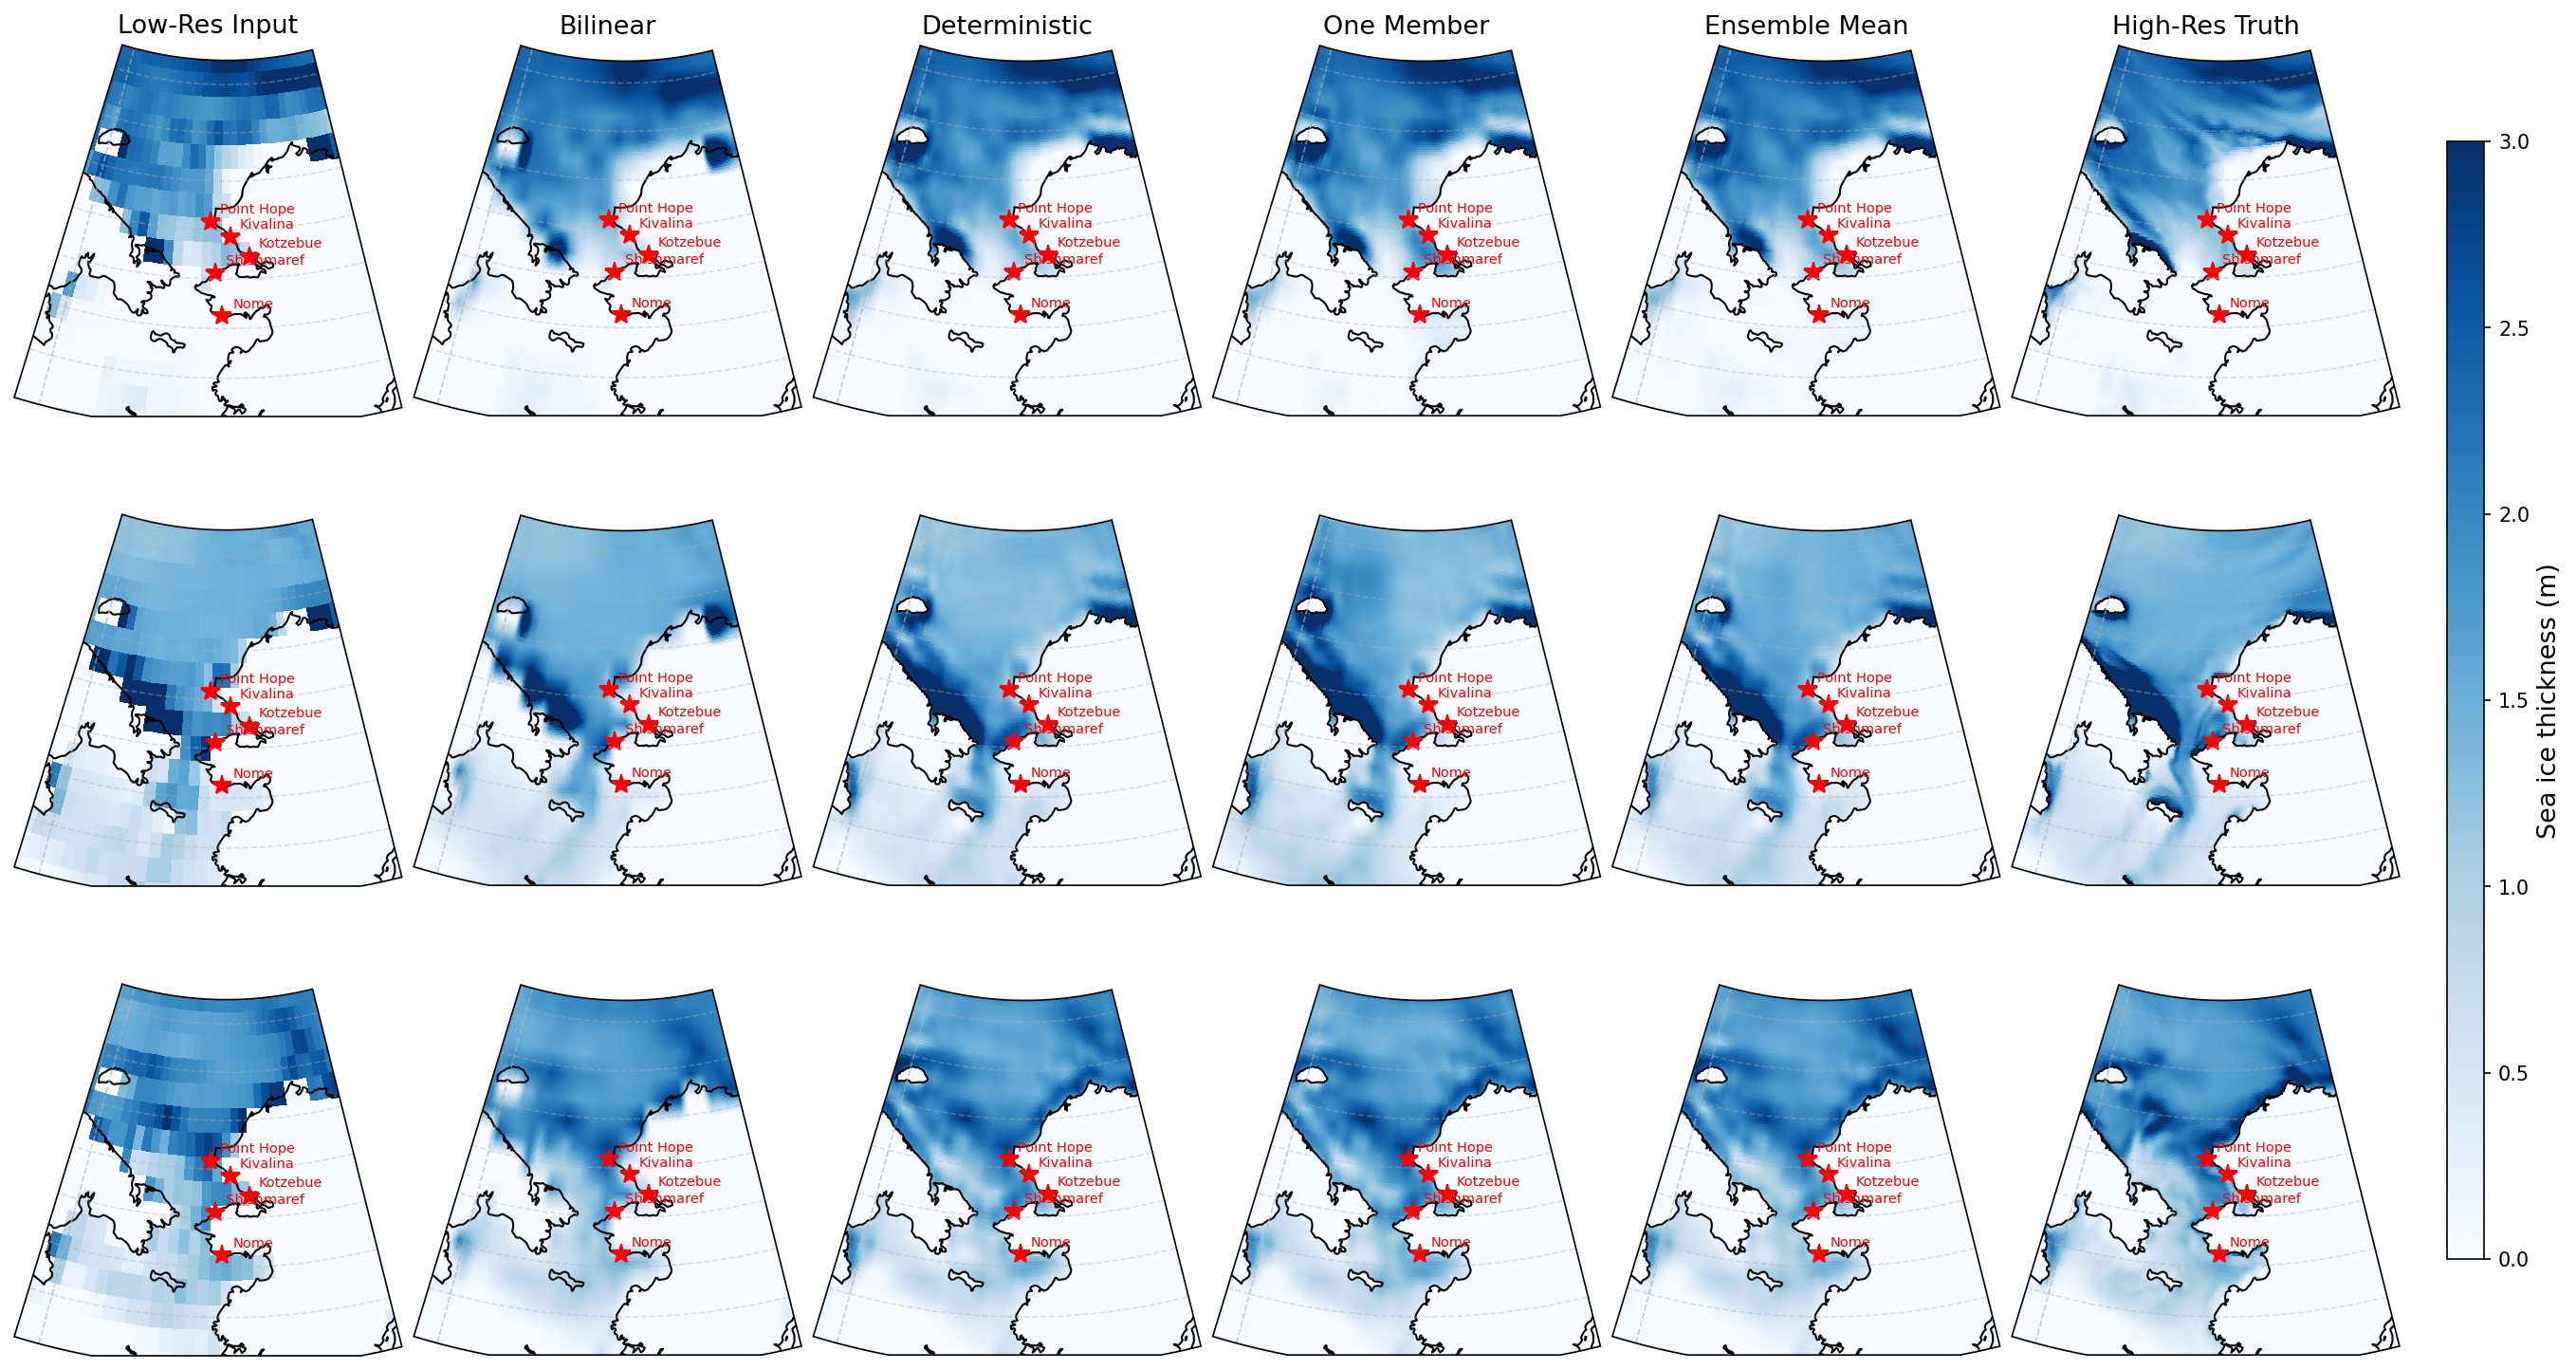

In [101]:
panel_titles = ["Low-Res Input", "Bilinear", "Deterministic", "One Member", "Ensemble Mean", "High-Res Truth"]

fig, axs = plt.subplots(
    len(SAMPLE_IDXS), 6, figsize=(18, 3.3 * len(SAMPLE_IDXS)), constrained_layout=True, dpi=150,
    subplot_kw={"projection": proj},
)
if len(SAMPLE_IDXS) == 1:
    axs = axs[None, :]

for row, idx in enumerate(SAMPLE_IDXS):
    geo = tile_geometry[int(test_tile_ids[idx])]
    ctx_lon, ctx_lat = geo["context_lon"], geo["context_lat"]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]

    fields_row = [
        X_test_sit_phys[idx, 0], Y_base_phys[idx, 0], Y_pred_det_phys[idx, 0],
        preds_all_phys[idx, MEMBER_IDX, 0], Y_pred_phys[idx, 0], Y_test_phys[idx, 0],
    ]
    lons = [ctx_lon, tgt_lon, tgt_lon, tgt_lon, tgt_lon, tgt_lon]
    lats = [ctx_lat, tgt_lat, tgt_lat, tgt_lat, tgt_lat, tgt_lat]

    for col, (field, lon_, lat_) in enumerate(zip(fields_row, lons, lats)):
        ax = axs[row, col]
        im = ax.pcolormesh(lon_, lat_, field, transform=ccrs.PlateCarree(), cmap=CMAP, vmin=VMIN, vmax=VMAX, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, lon_, lat_, points=candidate_points if SHOW_POINTS else {})
        if row == 0:
            ax.set_title(panel_titles[col], fontsize=13)

    axs[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=13)

cbar = fig.colorbar(im, ax=axs, aspect=30, shrink=0.8, pad=0.02)
cbar.set_label("Sea ice thickness (m)", fontsize=13)
save_fig(fig, "03_ensemble_figure")
plt.show()

## 4. Error figure (customizable)

Absolute error vs. truth for bilinear, deterministic, and ensemble mean,
for the same (or a different) set of test samples.

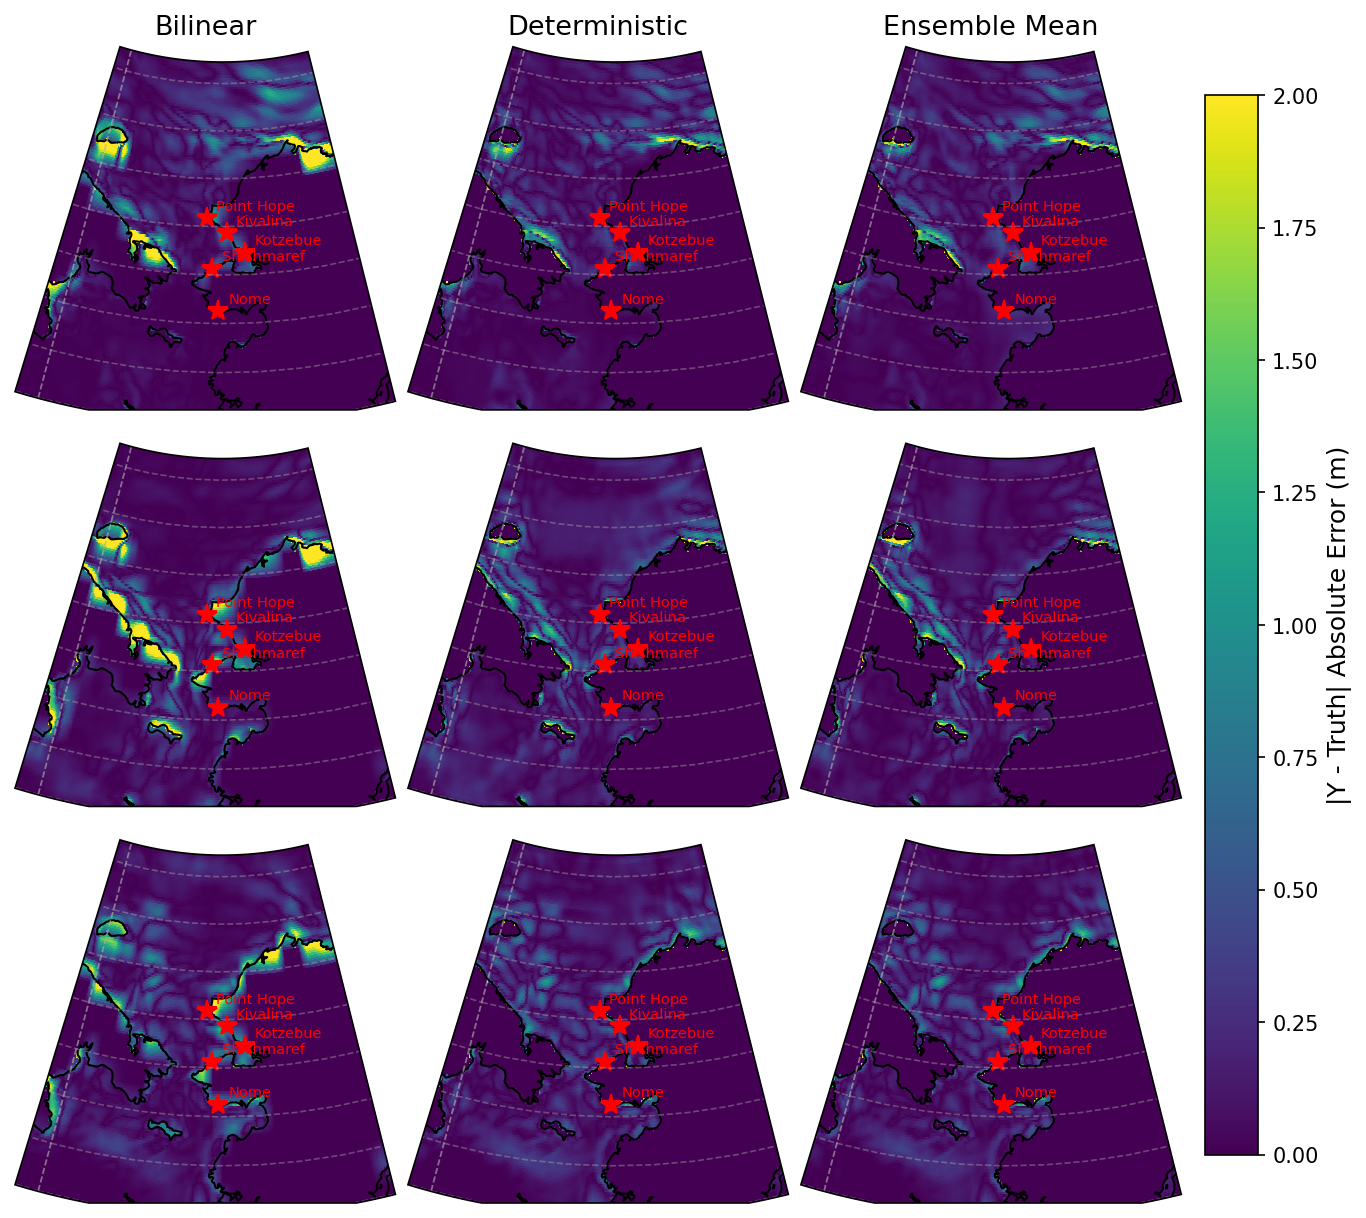

In [102]:
# ---- customize here ----
ERR_SAMPLE_IDXS = SAMPLE_IDXS   # reuse the same samples as above, or pick your own
ERR_VMIN, ERR_VMAX = 0, 2
ERR_CMAP = "viridis"
SHOW_POINTS = True
# -------------------------

panel_titles_err = ["Bilinear", "Deterministic", "Ensemble Mean"]

fig, axs = plt.subplots(
    len(ERR_SAMPLE_IDXS), 3, figsize=(9, 2.7 * len(ERR_SAMPLE_IDXS)), constrained_layout=True, dpi=150,
    subplot_kw={"projection": proj},
)
if len(ERR_SAMPLE_IDXS) == 1:
    axs = axs[None, :]

for row, idx in enumerate(ERR_SAMPLE_IDXS):
    geo = tile_geometry[int(test_tile_ids[idx])]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]

    truth = Y_test_phys[idx, 0]
    bilinear_ae = np.abs(Y_base_phys[idx, 0] - truth)
    det_ae = np.abs(Y_pred_det_phys[idx, 0] - truth)
    ens_ae = np.abs(Y_pred_phys[idx, 0] - truth)

    for col, field in enumerate([bilinear_ae, det_ae, ens_ae]):
        ax = axs[row, col]
        im = ax.pcolormesh(tgt_lon, tgt_lat, field, transform=ccrs.PlateCarree(), cmap=ERR_CMAP, vmin=ERR_VMIN, vmax=ERR_VMAX, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat, points=candidate_points if SHOW_POINTS else {})
        if row == 0:
            ax.set_title(panel_titles_err[col], fontsize=13)

    axs[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=13)

cbar = fig.colorbar(im, ax=axs, aspect=20, shrink=0.9, pad=0.02)
cbar.set_label("|Y - Truth| Absolute Error (m)", fontsize=12)
save_fig(fig, "04_error_figure")
plt.show()

## 5. Pattern correlation maps over time (e.g. the March SIT maximum)

The metrics above are *spatial* pattern correlation: for one time snapshot, correlate the
predicted and true 2D fields across space, then average over samples. This section instead
computes, for a chosen calendar month, the **temporal** correlation at each grid cell: fix
the pixel, correlate that pixel's predicted-vs-true value across all test years for that
month. The result is a 2D map per method showing *where* each method tracks the truth's
year-to-year variability well vs. poorly — March is the default since that's the
climatological Arctic sea-ice maximum, but any month works.

Only meaningful for `use_patches=False` runs (needs one coherent grid sampled repeatedly
over time, same reasoning as sections 1-2 above). Land cells (from `mask_test`) are masked
to `NaN`.

Month 3: 11 test years (2010-2020).


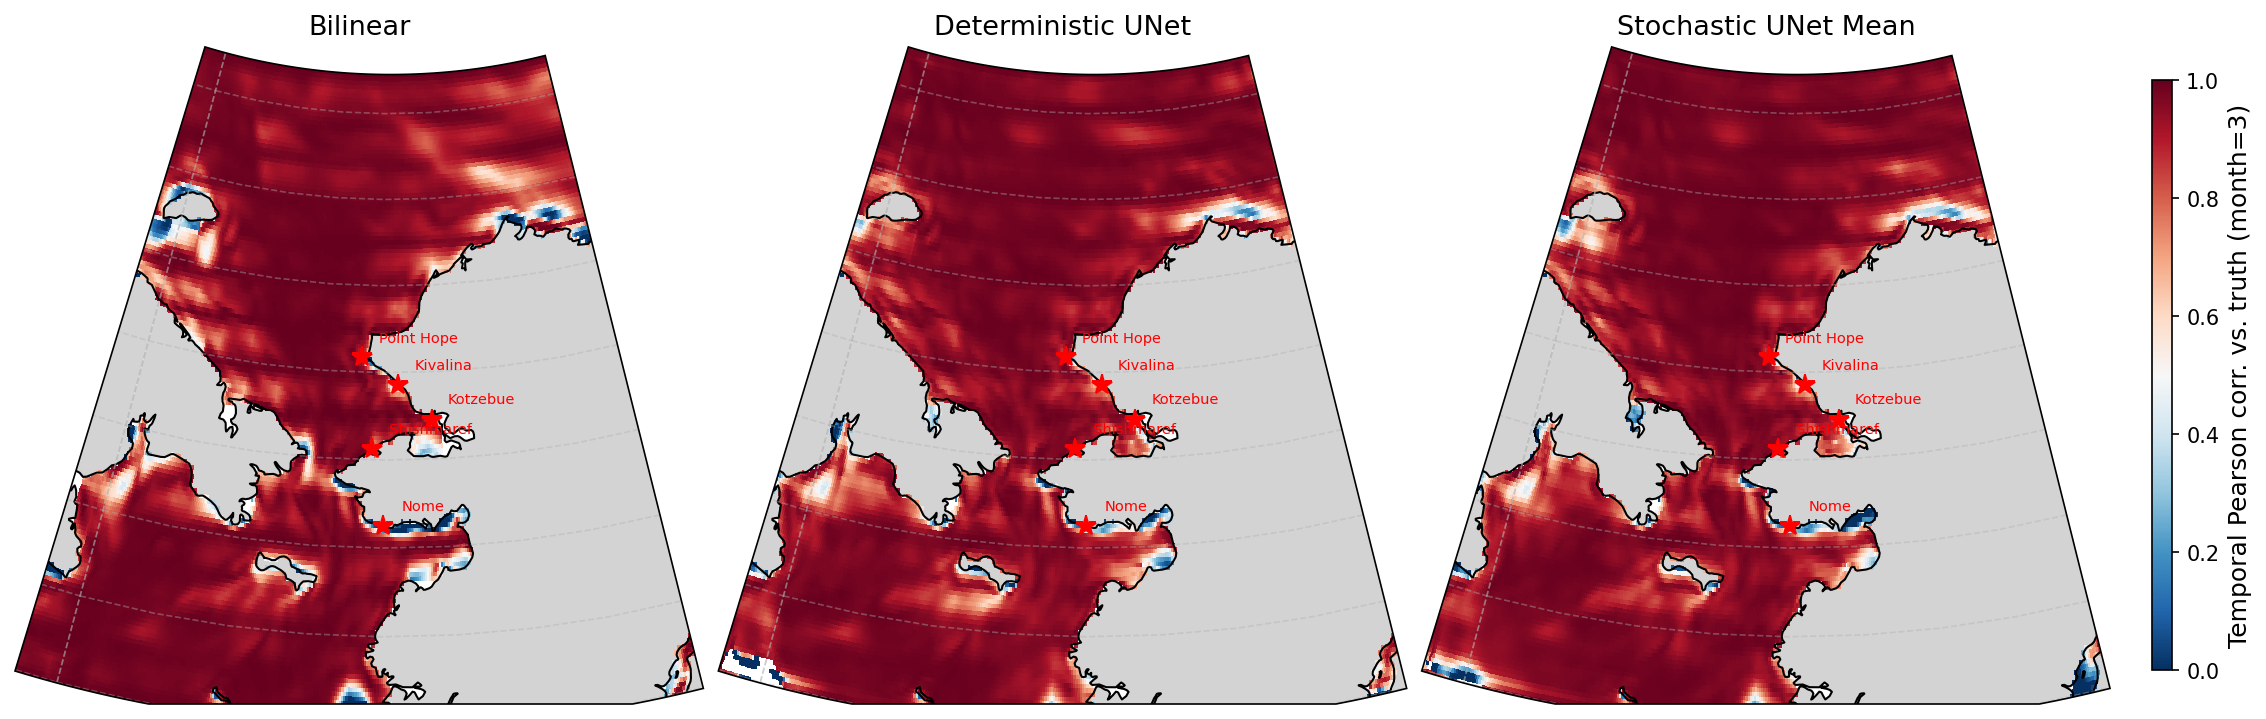

,Method,Domain mean temporal corr. (cos-lat weighted)
0,Bilinear,0.9012
1,Deterministic UNet,0.9139
2,Stochastic UNet Mean,0.9133


In [103]:
if use_patches:
    print("use_patches=True: no single coherent grid sampled repeatedly over time -- skipping.")
else:
    # ---- customize here ----
    MONTH = 3           # 1-12; 3 = March (climatological Arctic SIT/extent maximum)
    MIN_SAMPLES = 3      # need at least this many matching-month test samples for a stable corr
    MAP_CMAP = "RdBu_r"
    MAP_VMIN, MAP_VMAX = 0, 1
    SHOW_POINTS = True
    # -------------------------

    month_idx = np.where(sample_times_df["time"].dt.month.values == MONTH)[0]
    if len(month_idx) < MIN_SAMPLES:
        raise ValueError(
            f"Only {len(month_idx)} test samples fall in month {MONTH}, need at least {MIN_SAMPLES}."
        )
    print(f"Month {MONTH}: {len(month_idx)} test years "
          f"({sample_times_df['time'].iloc[month_idx].dt.year.min()}-"
          f"{sample_times_df['time'].iloc[month_idx].dt.year.max()}).")

    def temporal_pixel_corr(pred_phys, truth_phys, idx):
        """Per-pixel Pearson correlation across the time/sample axis.
        pred_phys/truth_phys: (N, 1, H, W); idx: which samples to correlate over."""
        p = pred_phys[idx, 0]  # (T, H, W)
        t = truth_phys[idx, 0]
        p_anom = p - p.mean(axis=0, keepdims=True)
        t_anom = t - t.mean(axis=0, keepdims=True)
        num = (p_anom * t_anom).sum(axis=0)
        den = np.sqrt((p_anom ** 2).sum(axis=0) * (t_anom ** 2).sum(axis=0))
        return np.divide(num, den, out=np.full_like(num, np.nan), where=den > 1e-8)

    geo = tile_geometry[0]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]
    land_hw = mask_test[0, 0] > 0.5

    methods_maps = {}
    for label, field in [
        ("Bilinear", Y_base_phys), ("Deterministic UNet", Y_pred_det_phys), ("Stochastic UNet Mean", Y_pred_phys),
    ]:
        corr_map = temporal_pixel_corr(field, Y_test_phys, month_idx)
        corr_map = np.where(land_hw, np.nan, corr_map)
        methods_maps[label] = corr_map

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, dpi=150,
                             subplot_kw={"projection": proj})
    for ax, (label, corr_map) in zip(axs, methods_maps.items()):
        im = ax.pcolormesh(tgt_lon, tgt_lat, corr_map, transform=ccrs.PlateCarree(),
                            cmap=MAP_CMAP, vmin=MAP_VMIN, vmax=MAP_VMAX, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat, points=candidate_points if SHOW_POINTS else {})
        ax.set_title(label, fontsize=13)

    cbar = fig.colorbar(im, ax=axs, aspect=30, shrink=0.8, pad=0.02)
    cbar.set_label(f"Temporal Pearson corr. vs. truth (month={MONTH})", fontsize=12)
    save_fig(fig, "05_pattern_corr_maps")
    plt.show()

    # Ocean-only, cos(lat)-weighted domain summary of each map -- same
    # weighting reasoning as the spatial Pattern Corr check above, applied
    # here to average the per-pixel temporal correlations into one number.
    ocean_w = np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon)))
    ocean_w = np.where(land_hw, 0.0, ocean_w)
    ocean_w = ocean_w / ocean_w.sum()

    summary = [
        {"Method": label, "Domain mean temporal corr. (cos-lat weighted)": round(float(np.nansum(ocean_w * corr_map)), 4)}
        for label, corr_map in methods_maps.items()
    ]
    summary_df = pd.DataFrame(summary)
    save_table(summary_df, "05_pattern_corr_summary")
    display(summary_df)

## 6. Spatial bias & variance-ratio maps (mean state, whole test record)

Two per-pixel maps, computed once over the full test record (not a single snapshot):
- **Time-mean bias**: `mean_t(pred) - mean_t(truth)` at each pixel — where each method runs
  systematically thick/thin, complementing the single domain-mean `Bias` in `metrics.csv`
  and the few-sample Error figure (section 4) above.
- **Std ratio**: `std_t(pred) / std_t(truth)` at each pixel — the spatial map version of the
  scalar `Spread/Error` ratio; values above/below 1 mean a method over-/under-disperses in
  time at that location.

Only meaningful for `use_patches=False` runs.

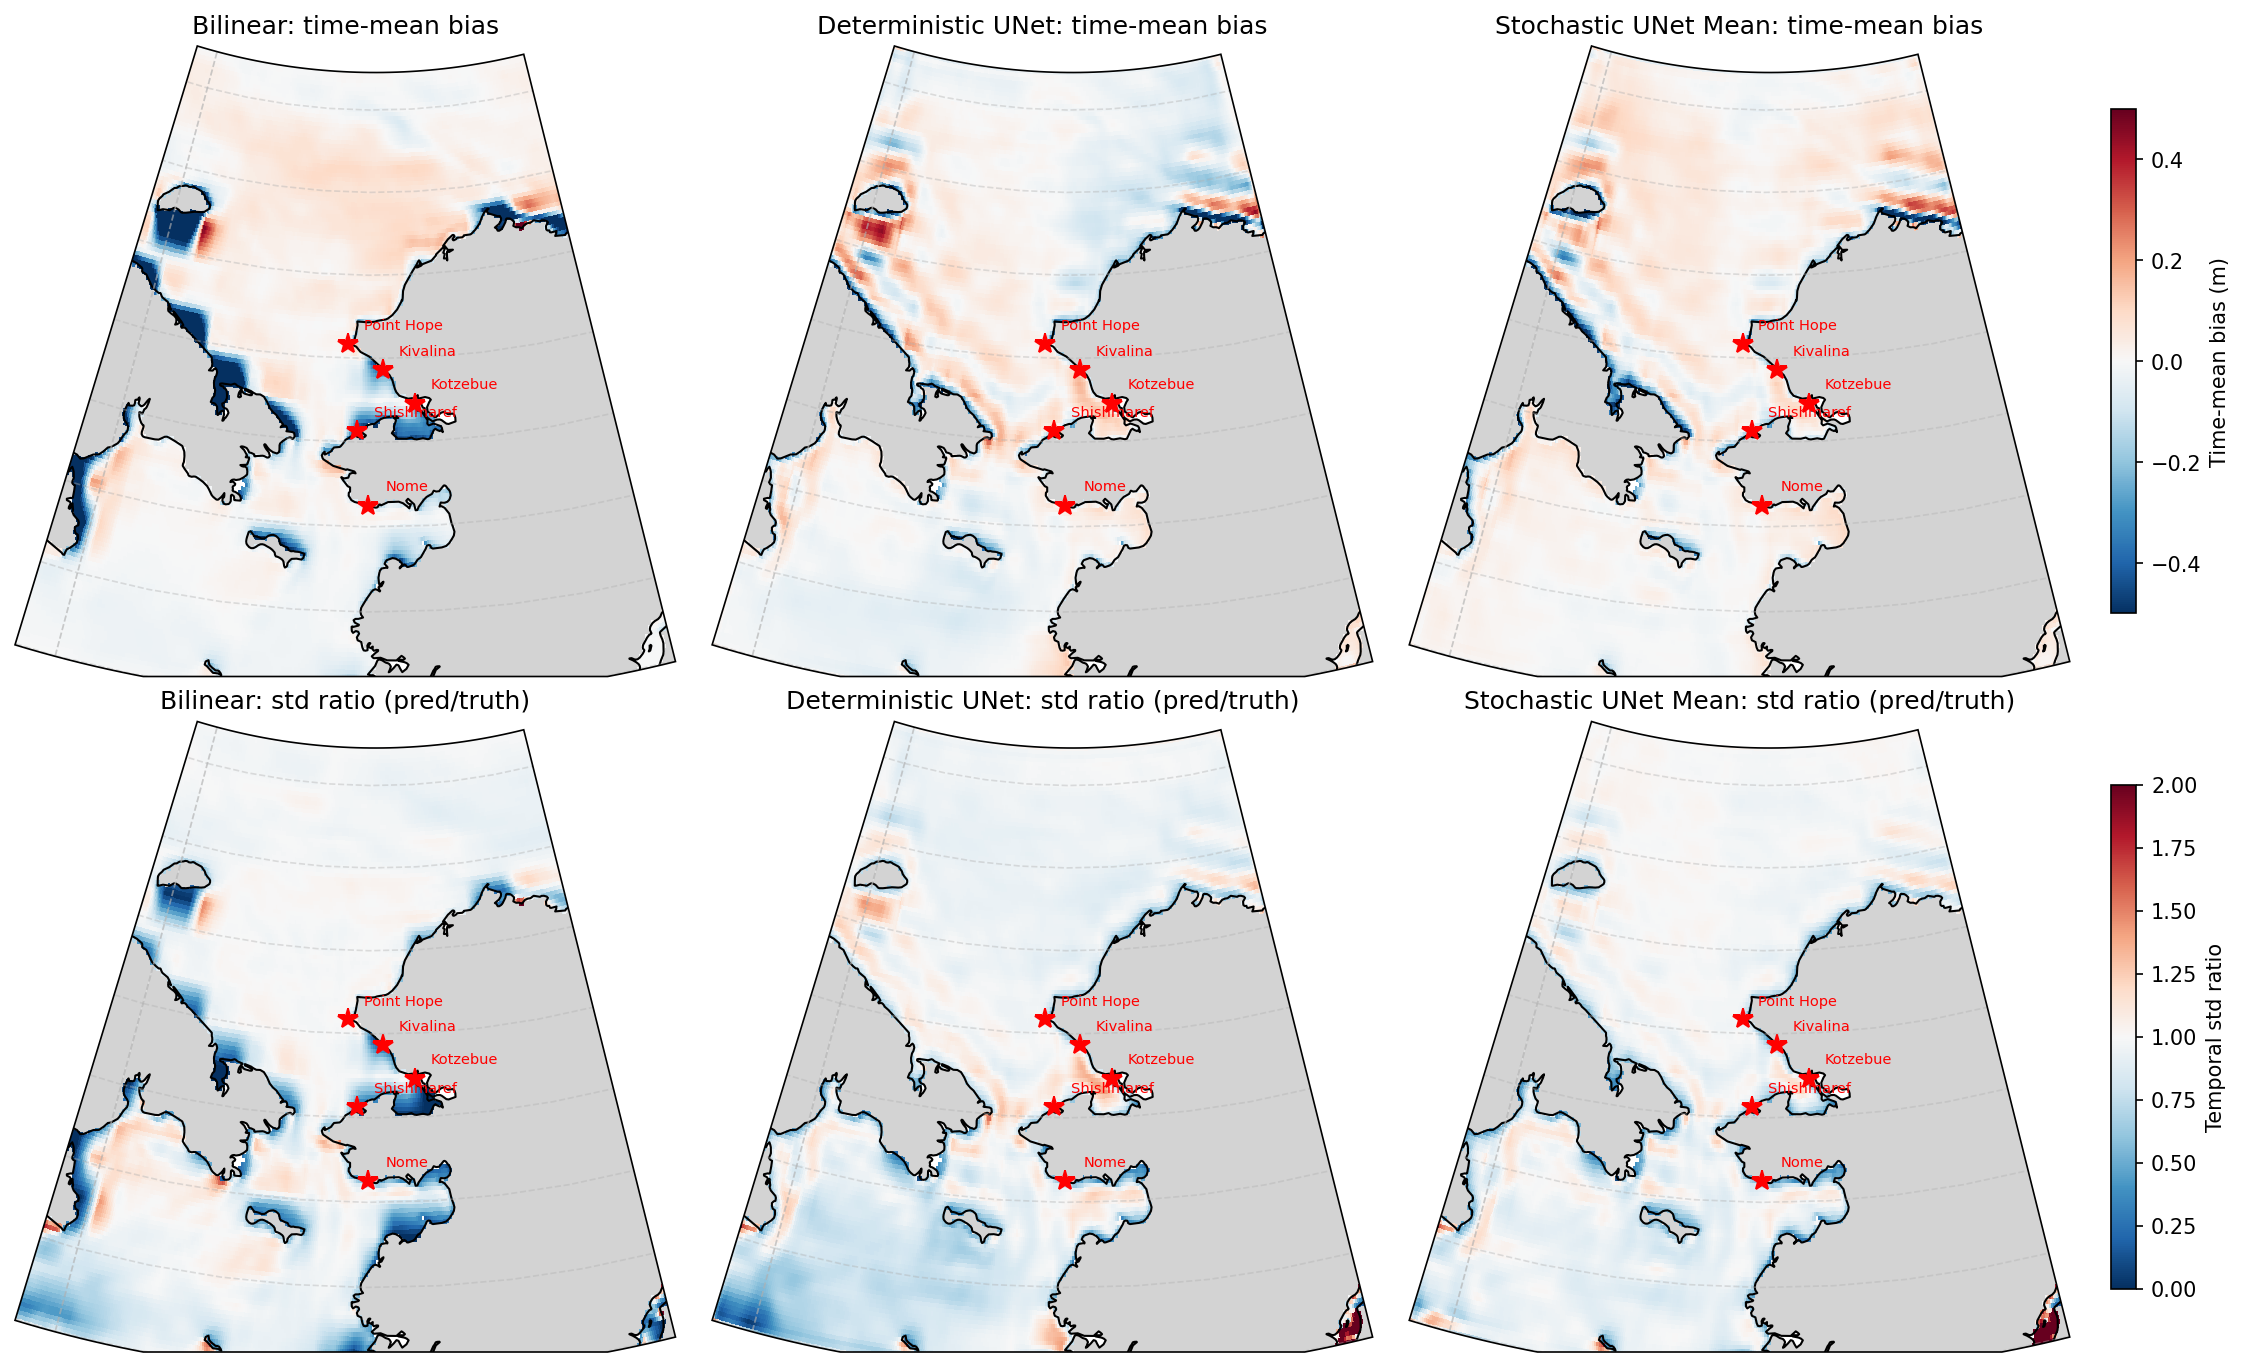

,Method,"Domain mean bias (cos-lat weighted, m)",Domain mean std ratio (cos-lat weighted)
0,Bilinear,-0.0277,0.9026
1,Deterministic UNet,-0.0115,0.9130
2,Stochastic UNet Mean,0.0085,0.9502


In [104]:
if use_patches:
    print("use_patches=True: no single coherent grid sampled repeatedly over time -- skipping.")
else:
    geo = tile_geometry[0]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]
    land_hw = mask_test[0, 0] > 0.5

    # ---- customize here ----
    BIAS_LIM = 0.5             # m; symmetric color limit for the bias maps
    STD_RATIO_LIM = (0, 2)     # std(pred)/std(truth); 1 = matches truth's temporal variability
    # -------------------------

    method_fields = {
        "Bilinear": Y_base_phys, "Deterministic UNet": Y_pred_det_phys, "Stochastic UNet Mean": Y_pred_phys,
    }

    truth_mean_hw = Y_test_phys[:, 0].mean(axis=0)
    truth_std_hw = Y_test_phys[:, 0].std(axis=0)

    bias_maps, std_ratio_maps = {}, {}
    for label, field in method_fields.items():
        pred_mean_hw = field[:, 0].mean(axis=0)
        pred_std_hw = field[:, 0].std(axis=0)
        bias_maps[label] = np.where(land_hw, np.nan, pred_mean_hw - truth_mean_hw)
        safe_truth_std = np.where(truth_std_hw > 1e-8, truth_std_hw, np.nan)
        std_ratio_maps[label] = np.where(land_hw, np.nan, pred_std_hw / safe_truth_std)

    fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True, dpi=150,
                             subplot_kw={"projection": proj})
    for col, (label, bmap) in enumerate(bias_maps.items()):
        ax = axs[0, col]
        im0 = ax.pcolormesh(tgt_lon, tgt_lat, bmap, transform=ccrs.PlateCarree(),
                             cmap="RdBu_r", vmin=-BIAS_LIM, vmax=BIAS_LIM, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat)
        ax.set_title(f"{label}: time-mean bias", fontsize=12)
    for col, (label, rmap) in enumerate(std_ratio_maps.items()):
        ax = axs[1, col]
        im1 = ax.pcolormesh(tgt_lon, tgt_lat, rmap, transform=ccrs.PlateCarree(), cmap="RdBu_r",
                             norm=TwoSlopeNorm(vcenter=1, vmin=STD_RATIO_LIM[0], vmax=STD_RATIO_LIM[1]),
                             shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat)
        ax.set_title(f"{label}: std ratio (pred/truth)", fontsize=12)

    fig.colorbar(im0, ax=axs[0, :], shrink=0.8, pad=0.02, label="Time-mean bias (m)")
    fig.colorbar(im1, ax=axs[1, :], shrink=0.8, pad=0.02, label="Temporal std ratio")
    save_fig(fig, "06_bias_std_ratio_maps")
    plt.show()

    ocean_w = np.where(land_hw, 0.0, np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon))))
    ocean_w = ocean_w / ocean_w.sum()

    summary = [{
        "Method": label,
        "Domain mean bias (cos-lat weighted, m)": round(float(np.nansum(ocean_w * bias_maps[label])), 4),
        "Domain mean std ratio (cos-lat weighted)": round(float(np.nansum(ocean_w * std_ratio_maps[label])), 4),
    } for label in method_fields]
    summary_df = pd.DataFrame(summary)
    save_table(summary_df, "06_bias_std_ratio_summary")
    display(summary_df)

## 7. Spatial trend maps

Per-pixel linear trend (OLS slope vs. time, in m/decade) for the truth and each method, over
the full test record. The FOSI record spans a long ice-decline period, so this checks
whether each method reproduces *where* thinning is fastest/slowest, not just the mean state
or its variability (sections 1 and 6 above) -- a method could nail the time-mean and std at a
pixel while still getting the sign or magnitude of its trend wrong.

Only meaningful for `use_patches=False` runs, and needs the test record to span enough years
for a stable slope estimate.

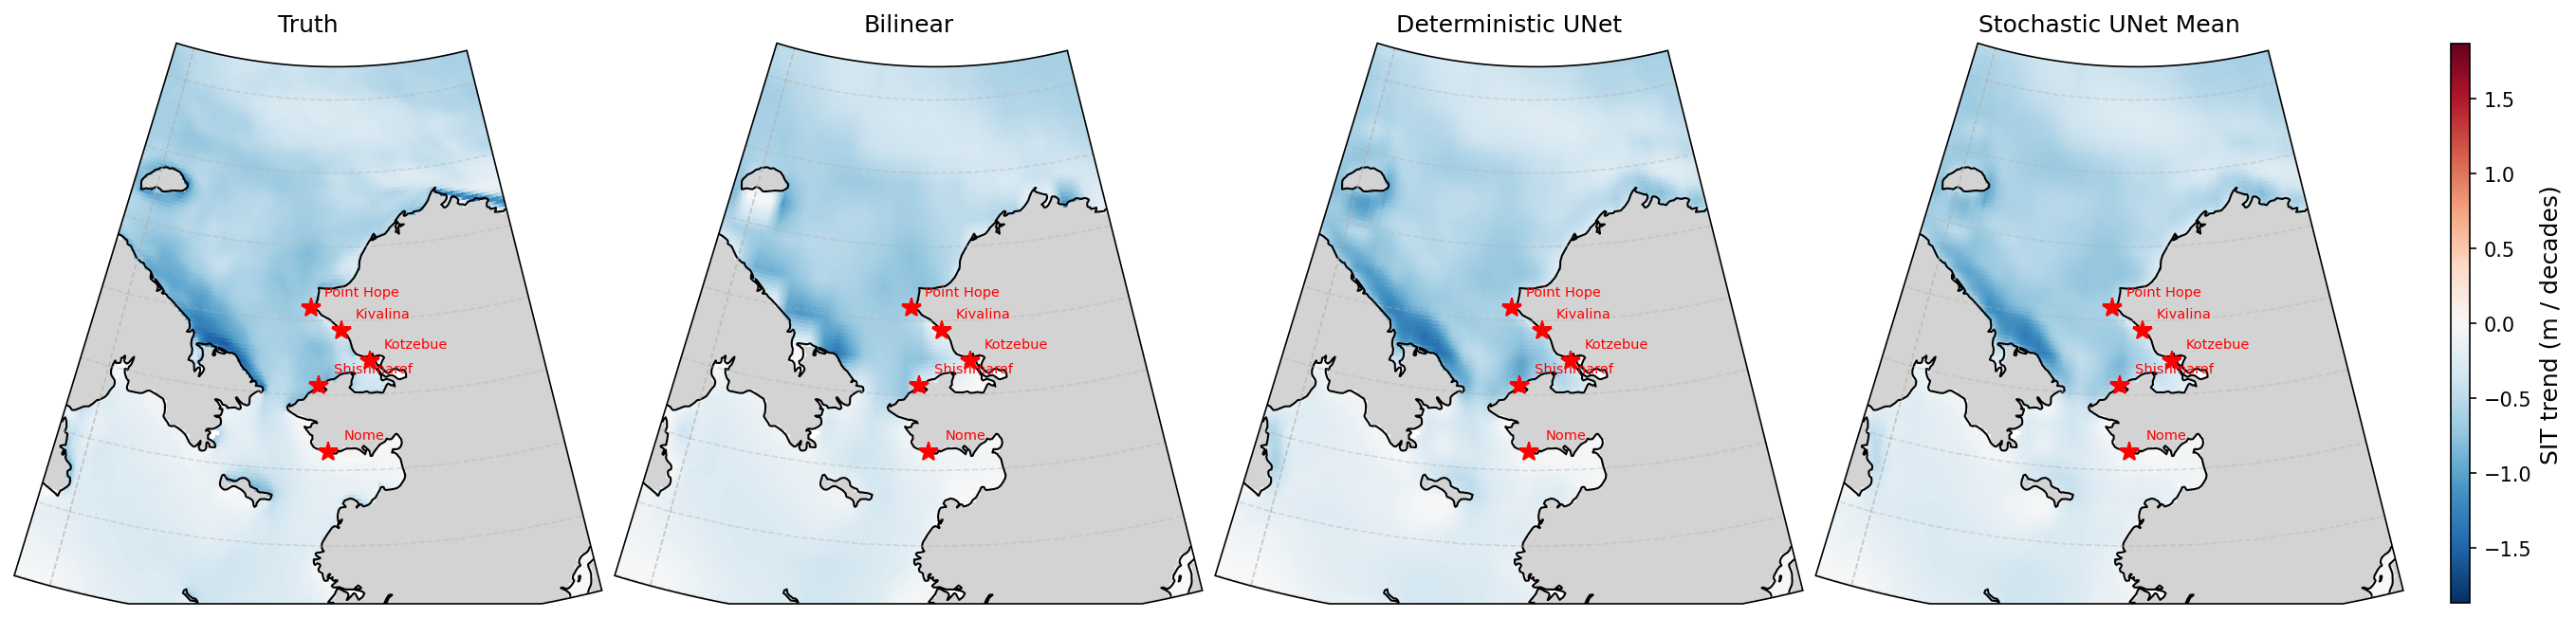

,Method,"Domain mean trend (cos-lat weighted, m/decade)",Trend bias vs. Truth (m/decade)
0,Truth,-0.4260,0.0000
1,Bilinear,-0.3926,0.0334
2,Deterministic UNet,-0.4016,0.0244
3,Stochastic UNet Mean,-0.4112,0.0148


In [105]:
if use_patches:
    print("use_patches=True: no single coherent grid sampled repeatedly over time -- skipping.")
else:
    MIN_YEARS_FOR_TREND = 5

    geo = tile_geometry[0]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]
    land_hw = mask_test[0, 0] > 0.5

    years = (sample_times_df["time"].dt.year + (sample_times_df["time"].dt.month - 1) / 12.0).values
    if years.max() - years.min() < MIN_YEARS_FOR_TREND:
        raise ValueError(
            f"Test record spans only {years.max() - years.min():.1f} years, "
            f"need at least {MIN_YEARS_FOR_TREND} for a stable trend estimate."
        )

    def pixel_trend_per_decade(field_phys, years):
        """Vectorized per-pixel OLS slope across the time/sample axis, in units/decade."""
        t = years - years.mean()
        y = field_phys[:, 0]  # (T, H, W)
        y_anom = y - y.mean(axis=0, keepdims=True)
        slope_per_year = (t[:, None, None] * y_anom).sum(axis=0) / (t ** 2).sum()
        return slope_per_year * 10.0

    method_fields = {
        "Truth": Y_test_phys, "Bilinear": Y_base_phys,
        "Deterministic UNet": Y_pred_det_phys, "Stochastic UNet Mean": Y_pred_phys,
    }
    trend_maps = {
        label: np.where(land_hw, np.nan, pixel_trend_per_decade(field, years))
        for label, field in method_fields.items()
    }

    TREND_LIM = float(np.nanmax(np.abs(trend_maps["Truth"])) * 1.2) or 0.1

    fig, axs = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True, dpi=150,
                             subplot_kw={"projection": proj})
    for ax, (label, tmap) in zip(axs, trend_maps.items()):
        im = ax.pcolormesh(tgt_lon, tgt_lat, tmap, transform=ccrs.PlateCarree(),
                            cmap="RdBu_r", vmin=-TREND_LIM, vmax=TREND_LIM, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat)
        ax.set_title(label, fontsize=12)

    cbar = fig.colorbar(im, ax=axs, aspect=30, shrink=0.8, pad=0.02)
    cbar.set_label("SIT trend (m / decades)", fontsize=12)
    save_fig(fig, "07_trend_maps")
    plt.show()

    ocean_w = np.where(land_hw, 0.0, np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon))))
    ocean_w = ocean_w / ocean_w.sum()

    truth_domain_trend = float(np.nansum(ocean_w * trend_maps["Truth"]))
    trend_summary = [{
        "Method": label,
        "Domain mean trend (cos-lat weighted, m/decade)": round(float(np.nansum(ocean_w * tmap)), 4),
        "Trend bias vs. Truth (m/decade)": (
            0.0 if label == "Truth" else round(float(np.nansum(ocean_w * tmap)) - truth_domain_trend, 4)
        ),
    } for label, tmap in trend_maps.items()]
    trend_summary_df = pd.DataFrame(trend_summary)
    save_table(trend_summary_df, "07_trend_summary")
    display(trend_summary_df)

## 8. Domain-mean bias time series

The single `Bias` number in `metrics.csv` is one value averaged over the whole test record.
This plots `domain_mean(pred) - domain_mean(truth)` at each test time (reusing `ts_df` and
`domain_mean` from section 1), to see whether bias is roughly constant, seasonal, or
trending/regime-dependent (e.g. worse in low-ice years).

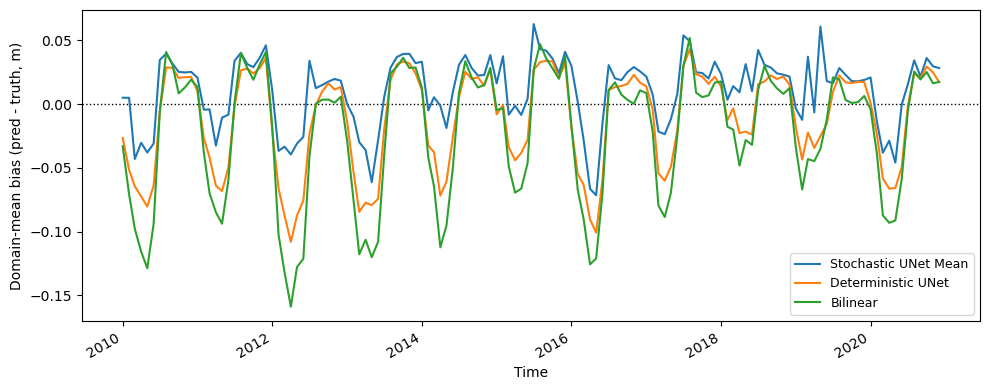

,bias_stochastic_unet_mean,bias_deterministic_unet,bias_bilinear
mean,0.0107,-0.0120,-0.0236
std,0.0272,0.0386,0.0511


In [106]:
if use_patches:
    print("use_patches=True: no single coherent domain to average over -- skipping.")
else:
    bias_df = ts_df.copy()
    bias_df["bias_stochastic_unet_mean"] = bias_df["stochastic_unet_mean"] - bias_df["truth"]
    bias_df["bias_deterministic_unet"] = bias_df["deterministic_unet"] - bias_df["truth"]
    bias_df["bias_bilinear"] = bias_df["bilinear"] - bias_df["truth"]

    # ---- customize here ----
    DATE_RANGE = None   # e.g. ("2006-01-01", "2010-12-31"), or None for all
    RESAMPLE = None      # e.g. "YS" (annual mean), "MS" (monthly), or None for raw samples
    BIAS_METHODS = {     # label -> (column, color)
        "Stochastic UNet Mean": ("bias_stochastic_unet_mean", "tab:blue"),
        "Deterministic UNet": ("bias_deterministic_unet", "tab:orange"),
        "Bilinear": ("bias_bilinear", "tab:green"),
    }
    # -------------------------

    plot_df = bias_df
    if DATE_RANGE is not None:
        plot_df = plot_df[(plot_df["time"] >= DATE_RANGE[0]) & (plot_df["time"] <= DATE_RANGE[1])]
    if RESAMPLE is not None:
        plot_df = plot_df.set_index("time").resample(RESAMPLE).mean(numeric_only=True).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axhline(0, color="black", linewidth=1, linestyle=":")
    for label, (col, color) in BIAS_METHODS.items():
        ax.plot(plot_df["time"], plot_df[col], label=label, color=color, linewidth=1.5)
    ax.set_ylabel("Domain-mean bias (pred - truth, m)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    save_fig(fig, "08_domain_bias_timeseries")
    plt.show()

    bias_cols = [col for _, (col, _) in BIAS_METHODS.items()]
    bias_stats_df = bias_df[bias_cols].agg(["mean", "std"]).round(4)
    save_table(bias_stats_df, "08_domain_bias_stats")
    display(bias_stats_df)

## 9. Seasonal climatology (mean annual cycle)

Domain-mean SIT averaged by calendar month across all test years (climatology), truth vs.
each method, plus the seasonal amplitude (max minus min month) each one produces. Checks
whether the freeze-thaw cycle's shape and amplitude are captured, independent of any
particular year's anomaly.

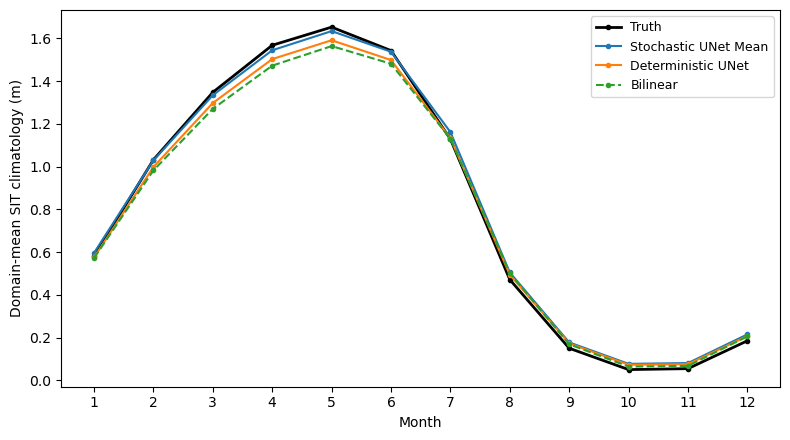

,Seasonal amplitude (m)
truth,1.6020
stochastic_unet_mean,1.5565
deterministic_unet,1.5178
bilinear,1.4992


In [107]:
if use_patches:
    print("use_patches=True: no single coherent domain to average over -- skipping.")
else:
    clim_df = ts_df.copy()
    clim_df["month"] = clim_df["time"].dt.month
    monthly_clim = clim_df.groupby("month")[["truth", "stochastic_unet_mean", "deterministic_unet", "bilinear"]].mean()

    CLIM_STYLE = {   # column -> (label, color, linestyle, linewidth)
        "truth": ("Truth", "black", "-", 2),
        "stochastic_unet_mean": ("Stochastic UNet Mean", "tab:blue", "-", 1.5),
        "deterministic_unet": ("Deterministic UNet", "tab:orange", "-", 1.5),
        "bilinear": ("Bilinear", "tab:green", "--", 1.5),
    }

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for col, (label, color, ls, lw) in CLIM_STYLE.items():
        ax.plot(monthly_clim.index, monthly_clim[col], label=label, color=color, linestyle=ls, linewidth=lw, marker="o", markersize=3)
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Domain-mean SIT climatology (m)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    save_fig(fig, "09_seasonal_climatology")
    plt.show()

    amplitude = (monthly_clim.max() - monthly_clim.min()).rename("Seasonal amplitude (m)")
    amplitude_df = amplitude.round(4).to_frame()
    save_table(amplitude_df, "09_seasonal_amplitude")
    display(amplitude_df)

## 10. Anomaly correlation (deseasonalized), all months

Section 5's temporal-correlation maps sidestep seasonality by fixing one calendar month
(all samples share nearly the same climatological state). This section instead uses **every**
test sample, but first removes each field's own per-calendar-month climatology (computed
over the test record) before correlating -- the standard "Anomaly Correlation Coefficient"
(ACC) used in forecast verification. Comparing it to the raw (non-deseasonalized) temporal
correlation over the same full record shows how much of that raw number is really just
"both curves have a seasonal cycle" rather than genuine interannual skill.

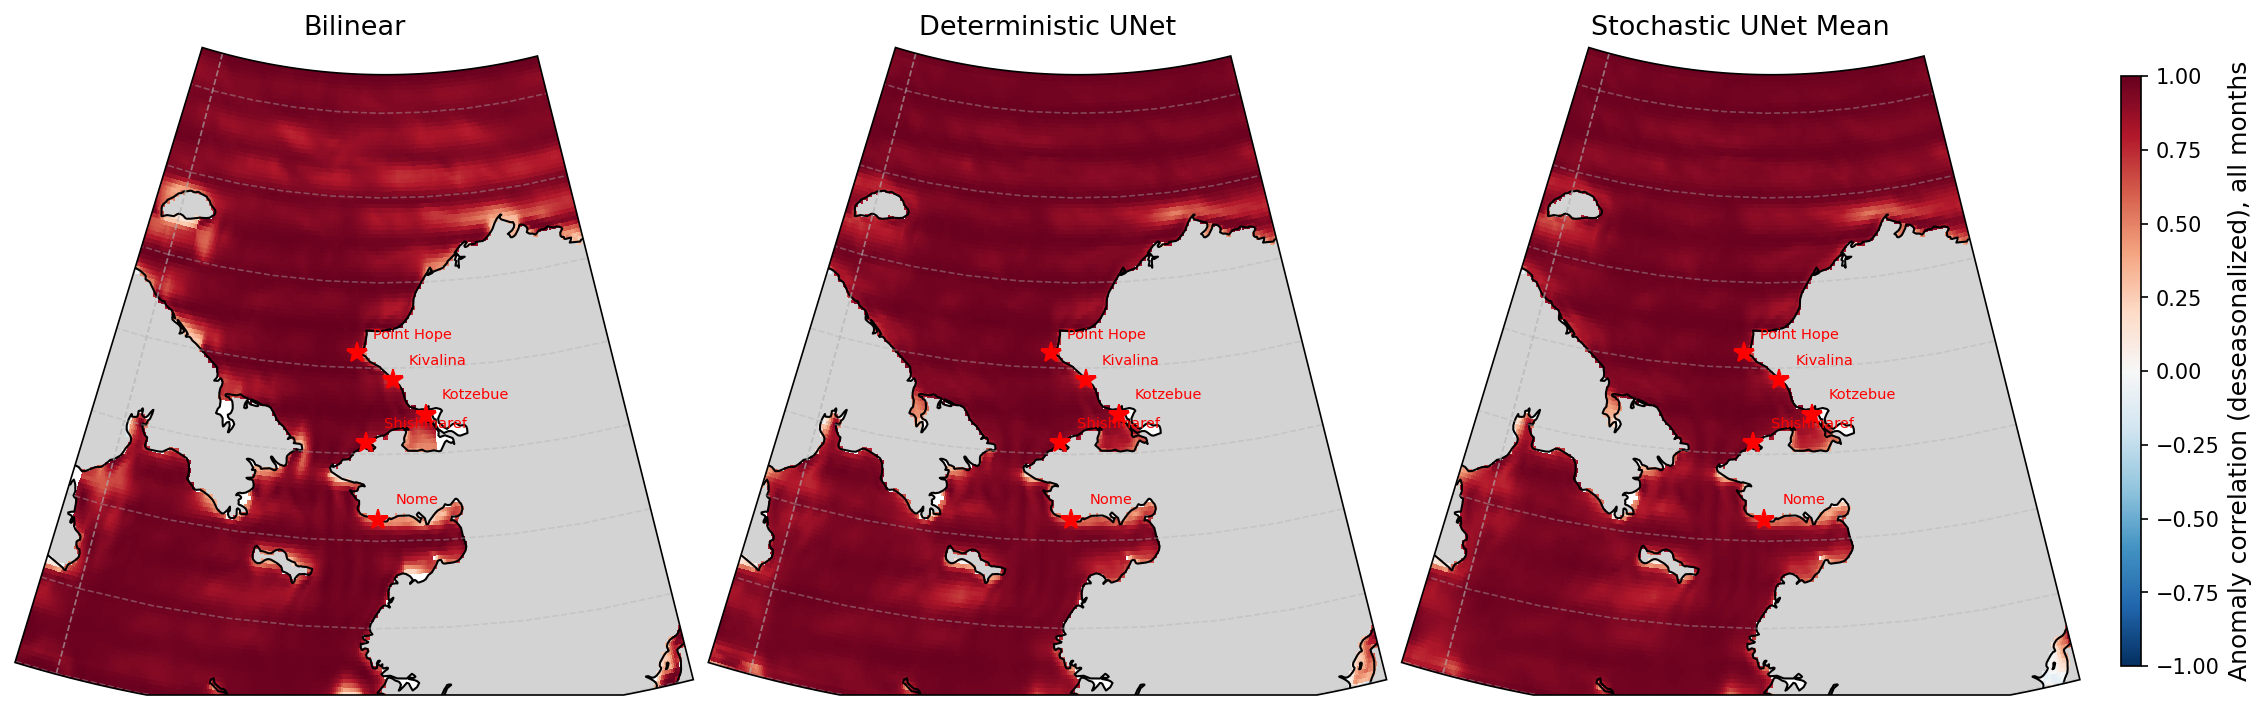

,Method,"Raw temporal corr., all months (cos-lat weighted)","Anomaly corr., all months (cos-lat weighted)"
0,Bilinear,0.9611,0.8985
1,Deterministic UNet,0.9676,0.9235
2,Stochastic UNet Mean,0.9658,0.9181


In [108]:
if use_patches:
    print("use_patches=True: no single coherent grid sampled repeatedly over time -- skipping.")
else:
    geo = tile_geometry[0]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]
    land_hw = mask_test[0, 0] > 0.5

    def remove_monthly_climatology(field_phys, months):
        """field_phys: (N, 1, H, W); months: (N,) calendar month per sample. Subtracts
        each pixel's own per-calendar-month mean (over the given samples)."""
        anom = np.empty_like(field_phys)
        for mo in range(1, 13):
            idx = np.where(months == mo)[0]
            if len(idx) == 0:
                continue
            clim = field_phys[idx].mean(axis=0, keepdims=True)
            anom[idx] = field_phys[idx] - clim
        return anom

    months = sample_times_df["time"].dt.month.values
    all_idx = np.arange(len(months))

    method_fields = {
        "Bilinear": Y_base_phys, "Deterministic UNet": Y_pred_det_phys, "Stochastic UNet Mean": Y_pred_phys,
    }
    truth_anom = remove_monthly_climatology(Y_test_phys, months)

    raw_maps, acc_maps = {}, {}
    for label, field in method_fields.items():
        raw_maps[label] = np.where(land_hw, np.nan, temporal_pixel_corr(field, Y_test_phys, all_idx))
        pred_anom = remove_monthly_climatology(field, months)
        acc_maps[label] = np.where(land_hw, np.nan, temporal_pixel_corr(pred_anom, truth_anom, all_idx))

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, dpi=150,
                             subplot_kw={"projection": proj})
    for ax, (label, amap) in zip(axs, acc_maps.items()):
        im = ax.pcolormesh(tgt_lon, tgt_lat, amap, transform=ccrs.PlateCarree(),
                            cmap="RdBu_r", vmin=-1, vmax=1, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat)
        ax.set_title(label, fontsize=13)
    cbar = fig.colorbar(im, ax=axs, aspect=30, shrink=0.8, pad=0.02)
    cbar.set_label("Anomaly correlation (deseasonalized), all months", fontsize=12)
    save_fig(fig, "10_anomaly_corr_maps")
    plt.show()

    ocean_w = np.where(land_hw, 0.0, np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon))))
    ocean_w = ocean_w / ocean_w.sum()

    acc_summary = [{
        "Method": label,
        "Raw temporal corr., all months (cos-lat weighted)": round(float(np.nansum(ocean_w * raw_maps[label])), 4),
        "Anomaly corr., all months (cos-lat weighted)": round(float(np.nansum(ocean_w * acc_maps[label])), 4),
    } for label in method_fields]
    acc_summary_df = pd.DataFrame(acc_summary)
    save_table(acc_summary_df, "10_anomaly_corr_summary")
    display(acc_summary_df)

## 11. Taylor diagram

Combines three of the statistics above -- correlation, normalized std, and centered RMSE --
into one plot per method, all computed over the combined space (`cos(lat)`-weighted, ocean
only) x time population of the full test record. Radius is `std(pred)/std(truth)`, angle is
`arccos(correlation)`, and the dashed gray arcs are contours of centered RMSE distance from
the truth reference point (black star at radius 1, angle 0 = a perfect match). A method
closer to the star is doing better on all three axes at once.

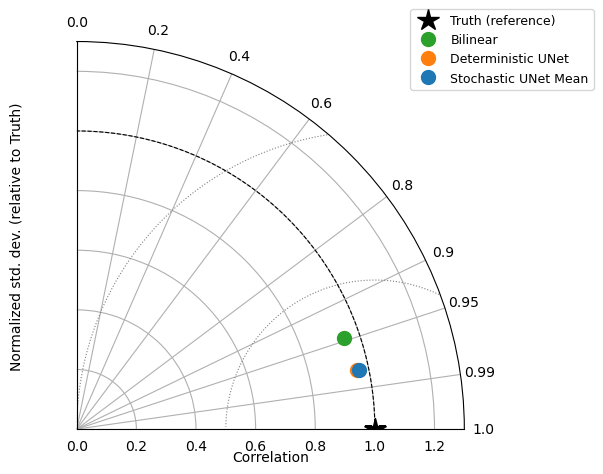

,Method,Correlation (R),Std Ratio,Centered RMSE (m)
0,Bilinear,0.9467,0.9466,0.2963
1,Deterministic UNet,0.9785,0.9621,0.1902
2,Stochastic UNet Mean,0.9785,0.9675,0.1901


In [109]:
if use_patches:
    print("use_patches=True: no single coherent grid sampled repeatedly over time -- skipping.")
else:
    geo = tile_geometry[0]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]
    land_hw = mask_test[0, 0] > 0.5

    method_fields = {
        "Bilinear": Y_base_phys, "Deterministic UNet": Y_pred_det_phys, "Stochastic UNet Mean": Y_pred_phys,
    }

    def weighted_stats(pred, truth, weight_hw):
        """Combined space+time weighted (R, std_ratio, centered_rmse): each sample
        weighted equally in time, each pixel weighted by weight_hw (land-masked,
        normalized to sum to 1) in space."""
        N = pred.shape[0]
        w = (weight_hw / N)[None, :, :]   # total weight sums to 1 across all N*H*W
        p, t = pred[:, 0], truth[:, 0]
        p_mean, t_mean = np.nansum(w * p), np.nansum(w * t)
        p_anom, t_anom = p - p_mean, t - t_mean
        var_p, var_t = np.nansum(w * p_anom ** 2), np.nansum(w * t_anom ** 2)
        cov = np.nansum(w * p_anom * t_anom)
        R = cov / np.sqrt(var_p * var_t)
        std_ratio = np.sqrt(var_p / var_t)
        crmse = np.sqrt(np.nansum(w * (p_anom - t_anom) ** 2))
        return float(R), float(std_ratio), float(crmse)

    ocean_w_hw = np.where(land_hw, 0.0, np.cos(np.deg2rad(tgt_lat))[:, None] * np.ones((1, len(tgt_lon))))
    ocean_w_hw = ocean_w_hw / ocean_w_hw.sum()

    taylor_stats = {label: weighted_stats(field, Y_test_phys, ocean_w_hw) for label, field in method_fields.items()}

    def rms_circle(center, radius, theta_lim=(0, np.pi / 2), n=200):
        t = np.linspace(0, 2 * np.pi, n)
        x, y = center[0] + radius * np.cos(t), center[1] + radius * np.sin(t)
        theta, r = np.arctan2(y, x), np.sqrt(x ** 2 + y ** 2)
        valid = (theta >= theta_lim[0]) & (theta <= theta_lim[1])
        return theta[valid], r[valid]

    max_std = max(sr for _, sr, _ in taylor_stats.values())
    r_lim = max(1.3, max_std * 1.2)

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = fig.add_subplot(111, polar=True)
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_ylim(0, r_lim)

    corr_ticks = np.array([0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
    ax.set_xticks(np.arccos(corr_ticks))
    ax.set_xticklabels([str(c) for c in corr_ticks])
    ax.set_xlabel("Correlation", labelpad=10)
    ax.set_ylabel("Normalized std. dev. (relative to Truth)", labelpad=30)

    for rms in np.arange(0.5, r_lim, 0.5):
        th, r = rms_circle((1, 0), rms)
        ax.plot(th, r, color="gray", linestyle=":", linewidth=0.8)

    std_circle_theta = np.linspace(0, np.pi / 2, 100)
    ax.plot(std_circle_theta, np.ones_like(std_circle_theta), color="black", linestyle="--", linewidth=0.8)
    ax.plot([0], [1], marker="*", color="black", markersize=16, linestyle="none", label="Truth (reference)")

    colors = {"Bilinear": "tab:green", "Deterministic UNet": "tab:orange", "Stochastic UNet Mean": "tab:blue"}
    for label, (R, std_ratio, crmse) in taylor_stats.items():
        ax.plot([np.arccos(np.clip(R, -1, 1))], [std_ratio], marker="o", markersize=10,
                color=colors.get(label, "tab:red"), linestyle="none", label=label)

    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    plt.tight_layout()
    save_fig(fig, "11_taylor_diagram")
    plt.show()

    taylor_df = pd.DataFrame([
        {"Method": label, "Correlation (R)": round(R, 4), "Std Ratio": round(std_ratio, 4), "Centered RMSE (m)": round(crmse, 4)}
        for label, (R, std_ratio, crmse) in taylor_stats.items()
    ])
    save_table(taylor_df, "11_taylor_stats")
    display(taylor_df)